<a href="https://colab.research.google.com/github/Akshitasaini1510/Assignment_1_week_2/blob/main/Netflix_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PART-A: Dataset Understanding**

Q1.
Load the dataset and display the first five records.

In [ ]:
import pandas as pd
df = pd.read_csv("Dataset 2.csv")
print(df.head())

   UserID  Age  Gender SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   22  Female            Basic                 23            5   
1    1002   55    Male            Basic                  9            4   
2    1003   49    Male            Basic                  8            3   
3    1004   39  Female          Premium                 19            5   
4    1005   38  Female          Premium                 23            5   

  FavoriteGenre  AdClicks  MonthlySpend SubscriptionRenewed  
0        Comedy        13           353                  No  
1         Drama        14           317                 Yes  
2        Comedy        16           309                  No  
3         Drama        45           833                 Yes  
4        Sci-Fi        24           804                 Yes  


Q2.
Determine the number of rows and columns in the dataset.



In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (750, 10)


Q3.
Display all column names.

In [ ]:
print(df.columns)

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


Q4.
Identify numerical and categorical features.

In [ ]:
print("Numerical Features:")
print(df.select_dtypes(include=['int64', 'float64']).columns)

print("\nCategorical Features:")
print(df.select_dtypes(include=['object']).columns)

Numerical Features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')

Categorical Features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


Q5.
Check whether the dataset contains missing values.

In [ ]:
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


**Part B: Exploratory Data Analysis**

Q6.
Calculate the average age of users.

In [ ]:
avg_age = df['Age'].mean()
print("Average Age:", avg_age)

Average Age: 41.824


Q7.
Determine the average watch hours per week.

In [ ]:
avg_watch = df['WatchHoursPerWeek'].mean()
print("Average Watch Hours Per Week:", avg_watch)

Average Watch Hours Per Week: 14.236


Q8.
Find the average monthly spending of users.

In [ ]:
avg_spend = df['MonthlySpend'].mean()
print("Average Monthly Spending:", avg_spend)

Average Monthly Spending: 689.9053333333334


Q9.
Count the number of users in each subscription category.

In [ ]:
subscription_count = df['SubscriptionType'].value_counts()
print(subscription_count)

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


Q10.
Determine the percentage of users who renewed their subscriptions.

In [ ]:
renewal_percentage = (df['SubscriptionRenewed'].value_counts(normalize=True) * 100)
print(renewal_percentage)

SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


**PART C: DATA PREPARATION**

Q11.
Convert categorical features into numerical form.



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['SubscriptionType'] = le.fit_transform(df['SubscriptionType'])
df['FavoriteGenre'] = le.fit_transform(df['FavoriteGenre'])
df['SubscriptionRenewed'] = le.fit_transform(df['SubscriptionRenewed'])

Q12.
Define the feature set (X) and target variable (y) for subscription renewal prediction

In [ ]:
X = df.drop('SubscriptionRenewed', axis=1)
y = df['SubscriptionRenewed']

Q13.
Split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

**Part D: Decision Tree Classification**

Q14.
Train a Decision Tree model to predict whether a user will renew their subscription.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Q15.
Evaluate the model using accuracy.

In [ ]:
from sklearn.metrics import accuracy_score
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.5666666666666667


Q16.
Generate and interpret the confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[50 32]
 [33 35]]


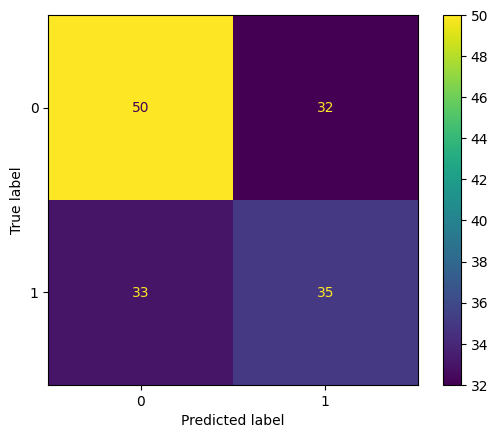

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot()

plt.show()

**Part E: K-Nearest Neighbors (KNN)**

Q17.
Train a KNN classifier with K = 5.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

Q18.
Compare the accuracy of KNN with the Decision Tree model.

In [ ]:
from sklearn.metrics import accuracy_score
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)
print("Decision Tree Accuracy:", accuracy_dt)

KNN Accuracy: 0.6
Decision Tree Accuracy: 0.5666666666666667


**Part F: Linear Regression**

Q19.
Train a Linear Regression model to predict monthly spending.

In [ ]:
from sklearn.model_selection import train_test_split

X_reg = df.drop('MonthlySpend', axis=1)
y_reg = df['MonthlySpend']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_reg, y_train_reg)

LinearRegression()

Q20.
Predict the monthly spending for a new user and interpret the result.

In [ ]:
new_user = [[
    2000,   # UserID
    30,     # Age
    1,      # Gender
    1,      # SubscriptionType
    15,     # WatchHoursPerWeek
    2,      # DevicesUsed
    2,      # FavoriteGenre
    20,     # AdClicks
    1       # SubscriptionRenewed
]]
predicted_spend = lr_model.predict(new_user)

print("Predicted Monthly Spending:", predicted_spend[0])

Predicted Monthly Spending: 824.8289104933519


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 1. Which factors appear to influence subscription renewal the most?

Based on the Decision Tree model, factors such as monthly spending, age, watch hours per week, and advertisement clicks seem to have the strongest influence on whether a user renews their subscription. Users who spend more money, watch content regularly, and engage more with the platform are generally more likely to renew their subscriptions.

# 2. Why is subscription renewal a classification problem?

Subscription renewal is a classification problem because the outcome belongs to one of two categories: "Yes" or "No". The goal of the model is to predict which category a user falls into, rather than predicting a numerical value.

# 3. Why is monthly spending a regression problem?

Monthly spending is a regression problem because the target variable is a continuous numerical value. The model predicts an exact amount of money that a user is expected to spend, such as ₹500, ₹750, or ₹1000, rather than assigning the user to a category.

# 4. Which algorithm performed better for renewal prediction?

In this analysis, the K-Nearest Neighbors (KNN) algorithm performed slightly better than the Decision Tree model. KNN achieved a higher accuracy score, indicating that it was more effective at predicting whether a user would renew their subscription.

# 5. How could the platform use these predictions to improve customer retention?

Netflix can use these predictions to identify users who are likely to cancel or not renew their subscriptions. The platform can then take proactive steps such as:
Offering personalized recommendations.
Providing discounts or special subscription offers.
Sending reminders and promotional messages.
Improving user engagement through targeted content.
By focusing on users who are at risk of leaving, Netflix can increase customer satisfaction and improve overall retention rates.